In [1]:
import pandas as pd

sales = pd.read_csv(r"D:\Practice Projects\GenAI\abia\data\sales_data.csv")
customers = pd.read_csv(r"D:\Practice Projects\GenAI\abia\data\customer_data.csv")
products = pd.read_csv(r"D:\Practice Projects\GenAI\abia\data\product_data.csv")

print("------Sales Head------")
display(sales.head(5))
print("------Customers Head------")
display(customers.head(5))
print("------Products Head------")
display(products.head(5))

------Sales Head------


,order_id,date,customer_id,product_id,revenue,quantity,region,channel
0,ORD_0,2023-02-19,CUST_268,PROD_83,1291.40,4,Asia,Mobile
1,ORD_1,2023-01-10,CUST_30,PROD_46,1417.68,3,Europe,Mobile
2,ORD_2,2023-02-26,CUST_285,PROD_99,940.26,2,North America,Web
3,ORD_3,2023-08-15,CUST_187,PROD_95,925.24,4,North America,Web
4,ORD_4,2023-08-18,CUST_441,PROD_12,151.47,3,North America,Web


------Customers Head------


,customer_id,signup_date,segment,country,churned
0,CUST_1,2022-05-21,Basic,Germany,True
1,CUST_2,2022-11-19,Basic,USA,False
2,CUST_3,2023-10-11,Basic,Germany,False
3,CUST_4,2024-03-31,Basic,USA,True
4,CUST_5,2022-03-10,Basic,Germany,False


------Products Head------


,product_id,category,price,cost
0,PROD_1,Electronics,203.49,88.331903
1,PROD_2,Sports,143.76,63.345721
2,PROD_3,Electronics,453.37,202.822390
3,PROD_4,Sports,470.78,273.673720
4,PROD_5,Home,121.26,80.039253


In [2]:
# 1. USER QUERY: Total revenue by region?
Q1 = sales.groupby("region")["revenue"].sum().round(2)
Q1

region
Asia              815677.26
Europe           1464607.69
North America     834741.62
Name: revenue, dtype: float64

In [3]:
# 2. USER QUERY: Top 5 products by total revenue?

# 1. Bring the product name column into the sales table
df_merged = pd.merge(sales, products, on="product_id", how="inner")

# 2. Group by product name and sum the revenue
Q2 = df_merged.groupby("product_id")["revenue"].sum().sort_values(ascending=False).head(5).round(2).reset_index()
Q2

,product_id,revenue
0,PROD_86,84763.66
1,PROD_87,66897.93
2,PROD_17,63616.90
3,PROD_78,63518.62
4,PROD_32,62291.10


In [4]:
# 3. USER QUERY: Revenue by customer segment in Europe?

# 1. Bring the customer segment column into the sales table
df_merged1 = pd.merge(sales, customers, on="customer_id", how="inner")

# 2. Filter for Europe, group by segment, and sum the revenue
Q3 = df_merged1[df_merged1["region"] == "Europe"].groupby("segment")["revenue"].sum().round(2).reset_index()
Q3

,segment,revenue
0,Basic,996669.17
1,Premium,467938.52


In [5]:
# 4. USER QUERY: Total revenue by sales channel

Q4 = sales.groupby("channel")["revenue"].sum().round(2)
Q4

channel
Mobile    1553095.65
Web       1561930.92
Name: revenue, dtype: float64

In [6]:
# 5. USER QUERY: Total revenue by product category in North America

# 1. Bring the product category column into the sales table (df_merged alredy exists)

# 2. Filter for North America, group by category, and sum the revenue
Q5 = df_merged[df_merged["region"] == "North America"].groupby("category")["revenue"].sum().round(2).reset_index()
Q5

,category,revenue
0,Clothing,178520.26
1,Electronics,325998.13
2,Home,178528.99
3,Sports,151694.24


In [7]:
# 6. USER QUERY: Revenue generated by churned vs active customers

# 1. Bring the churned column from the customers table to the sales table (df_merged1 already exists)
Q6 = df_merged1.groupby("churned")["revenue"].sum().round(2).reset_index()
Q6

,churned,revenue
0,False,2538217.76
1,True,576808.81


In [8]:
# 7. USER QUERY: Total revenue by product category for Premium customers in Europe

# Merge all the tables
df_all = sales.merge(customers, on="customer_id", how="left") \
              .merge(products, on="product_id", how="left")

# Filter for Europe and Premium customers, group by category, and sum the revenue
Q7 = df_all[(df_all["region"] == "Europe") & (df_all["segment"] == "Premium")].groupby("category")["revenue"].sum().round(2).reset_index()
Q7

,category,revenue
0,Clothing,95119.01
1,Electronics,186346.64
2,Home,93908.63
3,Sports,92564.24


In [9]:
# 8. USER QUERY: Top 5 products by total revenue
Q8 = (sales.groupby("product_id")["revenue"].sum().reset_index().sort_values(by="revenue", ascending=False).head(5))
Q8

,product_id,revenue
85,PROD_86,84763.66
86,PROD_87,66897.93
9,PROD_17,63616.90
76,PROD_78,63518.62
26,PROD_32,62291.10


In [10]:
# 9. USER QUERY: Top 3 product categories by total quantity sold

# Merge sales and products tables (df_merged already exists)

# Group by category and sum the quantity
Q9 = df_merged.groupby("category")["quantity"].sum().sort_values(ascending=False).head(3).reset_index()
Q9

,category,quantity
0,Electronics,4788
1,Sports,2890
2,Home,2429


In [11]:
# 10. USER QUERY: Total quantity sold by region

Q10 = sales.groupby("region")["quantity"].sum().reset_index()
Q10

,region,quantity
0,Asia,3085
1,Europe,6150
2,North America,3285


In [12]:
# 11. USER QUERY: Total revenue from Mobile channel for Premium customers

# Merge sales and customers tables (df_merged1 already exists)
Q11 = df_merged1[(df_merged1["channel"] == "Mobile") & (df_merged1["segment"] == "Premium")]["revenue"].sum().round(2)
Q11

np.float64(441459.59)

In [13]:
# 12. USER QUERY: Top selling product in India 

# Filter for India
df_india = df_merged1[df_merged1["country"] == "India"]

# Group by product_id to find the actual top 5 selling product in India
top_products_india = (
    df_india.groupby("product_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
    .head(5)
)

print("--- Top 5 Products by Revenue in India ---")
display(top_products_india)

--- Top 5 Products by Revenue in India ---


,product_id,revenue
85,PROD_86,27938.86
86,PROD_87,24064.00
23,PROD_3,22215.13
39,PROD_44,21726.32
20,PROD_27,20655.91


Total Sales Records: 5000
Regions available: <ArrowStringArray>
['Asia', 'Europe', 'North America']
Length: 3, dtype: str
--- Month-Wise Revenue Comparison Table ---


region,Asia,Europe
month,,
2023-01,"60,378.04","107,522.20"
2023-02,"67,881.48","116,453.06"
2023-03,"71,613.36","116,891.80"
2023-04,"57,044.37","104,829.90"
2023-05,"73,527.36","134,193.32"
2023-06,"68,340.87","132,951.61"
2023-07,"66,873.10","118,386.86"
2023-08,"82,080.41","151,174.99"
2023-09,"58,088.54","118,797.64"


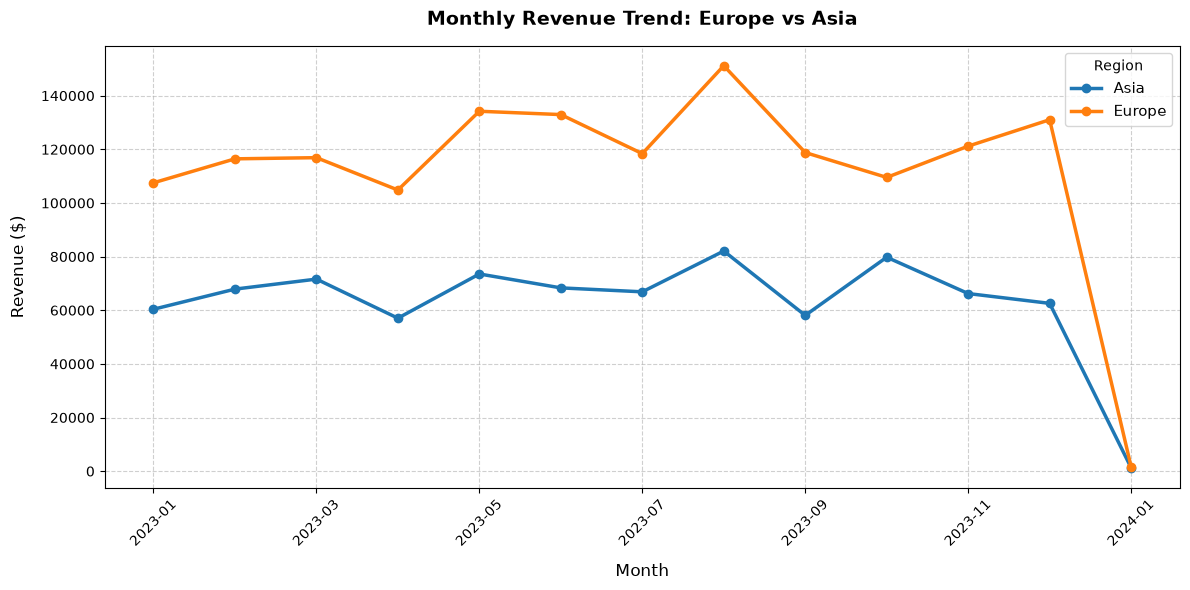

In [15]:
import matplotlib.pyplot as plt

# Format numbers with commas and 2 decimals
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

print(f"Total Sales Records: {len(sales)}")
print("Regions available:", sales['region'].unique())

# 1. Convert 'date' column to datetime and extract YYYY-MM month string
sales['date'] = pd.to_datetime(sales['date'])
sales['month'] = sales['date'].dt.to_period('M').astype(str)

# 2. Filter for Europe and Asia only
filtered_sales = sales[sales['region'].isin(['Europe', 'Asia'])]

# 3. Group by month and region, then sum revenue
trend_df = (
    filtered_sales.groupby(['month', 'region'])['revenue']
    .sum()
    .reset_index()
)

# 4. Pivot table so Month is the Index (X-axis) and Regions are Columns
pivot_df = trend_df.pivot_table(
    index='month', 
    columns='region', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

print("--- Month-Wise Revenue Comparison Table ---")
display(pivot_df)

# Plot line chart
ax = pivot_df.plot(kind='line', marker='o', figsize=(12, 6), linewidth=2.5)

plt.title("Monthly Revenue Trend: Europe vs Asia", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12, labelpad=10)
plt.ylabel("Revenue ($)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Region", fontsize=11)
plt.tight_layout()

plt.show()